# Analyse Exploratoire des Données (EDA) — Produits Technologiques Mytek.tn

## Décomposition hédonique du prix : 5 catégories de produits

---

**Contexte du projet.** Ce projet vise à **décomposer le prix** de produits technologiques en fonction de
leurs caractéristiques techniques (RAM, processeur, stockage, taille d'écran, technologie d'affichage, etc.),
en s'appuyant sur la **théorie des caractéristiques de Lancaster (1966)** et les **prix hédoniques de Rosen (1974)** :

> *Un bien n'est pas acheté pour lui-même, mais pour l'ensemble de ses caractéristiques qui lui confèrent de l'utilité.*

Autrement dit, le prix observé d'un produit est la **somme des prix implicites** de ses attributs. Avant de
modéliser cette relation (régression hédonique), il est indispensable de **comprendre et nettoyer les données**.

**Objectif de ce notebook.** Réaliser une analyse exploratoire (EDA) claire et structurée de l'intégralité des
données collectées afin de :
1. Comprendre la **structure** et la **qualité** des données, catégorie par catégorie ;
2. Décrire la **distribution des prix** et des caractéristiques pour **chaque type de produit** ;
3. Étudier les **relations** entre attributs techniques et prix ;
4. Préparer le terrain pour la **modélisation hédonique**.

**Données.** Cinq fichiers JSON collectés depuis Mytek.tn (`data/raw/week_1/`), un par catégorie :

| Catégorie | Fichier | Produits |
|---|---|---|
| PC de Bureau | `produits_pc_bureau_*.json` | 221 |
| PC Portables | `produits_pc_portables_*.json` | 541 |
| Smartphones | `produits_smartphones_*.json` | 254 |
| Téléphones Portables | `produits_telephones_portables_*.json` | 70 |
| Téléviseurs | `produits_televiseurs_*.json` | 112 |

**Total : 1 198 produits** répartis sur 5 catégories technologiques.


## 0. Configuration de l'environnement

On importe les bibliothèques nécessaires et on fixe un style graphique homogène pour tout le notebook.
La palette de couleurs par catégorie est **fixe** (même couleur pour une catégorie donnée dans tous les
graphiques du notebook) afin de faciliter la lecture visuelle d'une section à l'autre.

In [1]:
import json
import re
import sys
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# Racine du depot -- necessaire pour importer src.preprocessing.clean (les
# bornes de plausibilite VALIDITY_BOUNDS, reutilisees en §2.3.1 pour que
# l'EDA emploie exactement les memes bornes que le pipeline de nettoyage,
# plutot qu'une copie locale qui pourrait diverger silencieusement).
REPO_ROOT = Path.cwd().resolve().parents[0]
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))

# --- Style graphique homogène ---
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- Catégories et palette fixe (ordre stable, jamais recyclé) ---
CATEGORY_ORDER = ["pc_bureau", "pc_portables", "smartphones", "telephones_portables", "televiseurs"]
CATEGORY_LABELS = {
    "pc_bureau": "PC de Bureau",
    "pc_portables": "PC Portables",
    "smartphones": "Smartphones",
    "telephones_portables": "Téléphones Portables",
    "televiseurs": "Téléviseurs",
}
PALETTE = {
    "pc_bureau": "#2a78d6",             # bleu
    "pc_portables": "#1baf7a",          # aqua
    "smartphones": "#eda100",           # jaune
    "telephones_portables": "#4a3aa7",  # violet
    "televiseurs": "#e34948",           # rouge
}

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## 1. Chargement des données

Les 5 fichiers JSON partagent le **même schéma de base** (15 champs), complété par **5 champs additionnels
spécifiques aux téléviseurs** (`resolution_affichage`, `technologie_dalle`, `hdr`, `smart_tv`,
`taux_rafraichissement`). On charge chaque fichier dans un DataFrame séparé, on ajoute une colonne `source`,
puis on concatène le tout dans un DataFrame unifié `df` qui sert de base à l'analyse comparative.

Le chargement se fait par **recherche automatique** (`glob`) du fichier le plus récent par catégorie dans
`data/raw/week_1/` — les éventuels fichiers `*_partial.json` (sauvegardes intermédiaires du scraper, incomplètes
par construction) sont explicitement exclus pour ne jamais compter un produit deux fois.

In [2]:
RAW_DIR = Path.cwd().resolve().parents[0] / "data" / "raw" / "week_1"
if not RAW_DIR.exists():
    # Filet de sécurité si le notebook est lancé depuis un autre répertoire de travail
    RAW_DIR = Path("data/raw/week_1").resolve()

print("Répertoire de données :", RAW_DIR)

frames = []
for cat_key in CATEGORY_ORDER:
    candidates = sorted(
        f for f in RAW_DIR.glob(f"produits_{cat_key}_*.json")
        if "partial" not in f.name
    )
    if not candidates:
        print(f"{cat_key:<22} : AUCUN FICHIER TROUVÉ")
        continue
    path = candidates[-1]  # le plus récent (tri lexicographique = tri chronologique, timestamp ISO)
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    tmp = pd.DataFrame(data)
    tmp["source"] = cat_key
    frames.append(tmp)
    print(f"{cat_key:<22} : {len(tmp):>4} produits  ({path.name})")

df = pd.concat(frames, ignore_index=True)
print(f"\n{'TOTAL':<22} : {len(df):>4} produits, {df['source'].nunique()} catégories")

Répertoire de données : C:\Users\MSI\Desktop\stage\data\raw\week_1
pc_bureau              :  221 produits  (produits_pc_bureau_2026-07-02_20-09-55.json)
pc_portables           :  541 produits  (produits_pc_portables_2026-07-02_19-25-50.json)
smartphones            :  254 produits  (produits_smartphones_2026-07-03_02-06-45.json)
telephones_portables   :   70 produits  (produits_telephones_portables_2026-06-30_06-03-54.json)
televiseurs            :  112 produits  (produits_televiseurs_2026-07-03_23-43-26.json)

TOTAL                  : 1198 produits, 5 catégories


### 1.1 Aperçu des premières lignes

In [3]:
df.head(3)

,url,nom,marque,prix_tnd,processeur,ram_go,stockage_go,type_stockage,taille_ecran,os,connectivite,categorie,semaine,date_collecte,specs_brutes,source,resolution_affichage,technologie_dalle,hdr,smart_tv,taux_rafraichissement
0,https://www.mytek.tn/mini-pc-de-bureau-bmax-b3...,Mini PC de Bureau BMAX B3 Pro N5095 8Go 256Go SSD,BMAX,569.00,Intel Jasper Lake N5095 (2.00 GHz up to 2.90 G...,8.00,256.00,SSD,3.00,Windows 11,Wi-Fi,pc_bureau,1,2026-07-02 19:30:37,"{'DISPONIBILITÉ': 'En stock', 'gtin': 'BMAX-B3...",pc_bureau,NaN,NaN,NaN,NaN,NaN
1,https://www.mytek.tn/mini-pc-de-bureau-bmax-b6...,Mini PC de Bureau BMAX B6 Plus i3 10è Gén 12Go...,BMAX,829.00,"Intel Core i3-1000NG4 (1,10 GHz up to 3,20 GHz...",12.00,512.00,SSD,6.00,Windows 11,Wi-Fi,pc_bureau,1,2026-07-02 19:30:45,"{'DISPONIBILITÉ': 'Epuisé', 'gtin': 'BMAX-B6PL...",pc_bureau,NaN,NaN,NaN,NaN,NaN
2,https://www.mytek.tn/pc-de-bureau-pro-mytek-in...,Pc de Bureau Pro MYTEK Intel Celeron G5900 16G...,MYTEK,829.00,"Intel Celeron G5900 (3,40 GHz, 2Mo Mémoire cac...",16.00,240.00,SSD,NaN,FreeDos,NaN,pc_bureau,1,2026-07-02 19:30:52,"{'DISPONIBILITÉ': 'Epuisé', 'gtin': 'SHIELD-G5...",pc_bureau,NaN,NaN,NaN,NaN,NaN


### 1.2 Schéma et types de colonnes

Les 5 champs `resolution_affichage`, `technologie_dalle`, `hdr`, `smart_tv`, `taux_rafraichissement` n'existent
que pour la catégorie `televiseurs` — ils apparaissent comme `NaN` pour toutes les autres lignes, ce qui est
attendu (pas une erreur).

In [4]:
print("Dimensions :", df.shape)
print("\n--- Types de données ---")
df.dtypes

Dimensions : (1198, 21)

--- Types de données ---


url                          str
nom                          str
marque                       str
prix_tnd                 float64
processeur                   str
ram_go                   float64
stockage_go              float64
type_stockage             object
taille_ecran             float64
os                           str
connectivite                 str
categorie                    str
semaine                    int64
date_collecte                str
specs_brutes              object
source                       str
resolution_affichage         str
technologie_dalle            str
hdr                       object
smart_tv                  object
taux_rafraichissement    float64
dtype: object

**Interprétation.** Le jeu de données unifié contient **1 198 produits** sur **21 colonnes** (15 champs
communs + 5 champs spécifiques aux téléviseurs + `source`). Les variables clés pour l'analyse hédonique sont :

| Colonne | Rôle | Type | Catégories concernées |
|---|---|---|---|
| `prix_tnd` | **Variable cible** (prix en dinars tunisiens) | numérique | toutes |
| `ram_go`, `stockage_go`, `taille_ecran` | Caractéristiques quantitatives communes | numérique | toutes |
| `marque`, `type_stockage`, `os`, `connectivite`, `processeur` | Caractéristiques qualitatives communes | catégoriel | toutes |
| `resolution_affichage`, `technologie_dalle`, `hdr`, `smart_tv`, `taux_rafraichissement` | Caractéristiques spécifiques | catégoriel/bool | téléviseurs uniquement |
| `specs_brutes` | Spécifications brutes (dictionnaire, non aplati) | objet | toutes |


## 2. Qualité des données

Avant toute analyse, on évalue la **fiabilité** de chaque catégorie : valeurs manquantes, doublons et cohérence
des valeurs. C'est une étape critique car un modèle hédonique est très sensible aux valeurs aberrantes — et,
comme on va le voir, cette collecte en contient.

### 2.1 Valeurs manquantes par catégorie

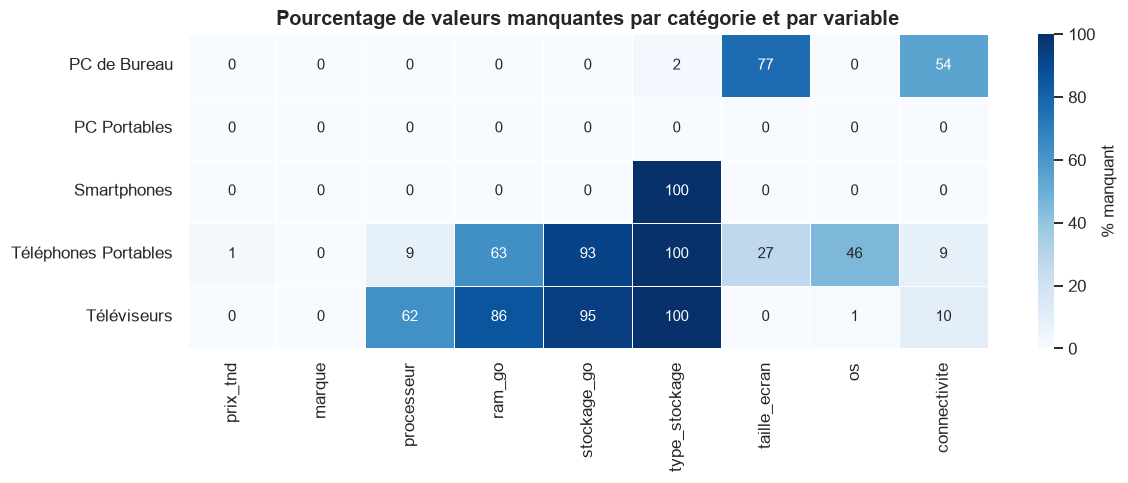

In [5]:
cols_of_interest = [
    "prix_tnd", "marque", "processeur", "ram_go", "stockage_go", "type_stockage",
    "taille_ecran", "os", "connectivite",
]
missing_pct = (
    df.groupby("source")[cols_of_interest]
      .apply(lambda g: g.isna().mean().mul(100).round(1))
      .reindex(CATEGORY_ORDER)
)
missing_pct.index = [CATEGORY_LABELS[c] for c in missing_pct.index]

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(missing_pct, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            linewidths=.5, cbar_kws={"label": "% manquant"}, ax=ax)
ax.set_title("Pourcentage de valeurs manquantes par catégorie et par variable")
plt.tight_layout(); plt.show()

**Interprétation.**
- `type_stockage` est manquant pour la quasi-totalité des **smartphones** et **téléphones portables** : ces
  fiches produit ne distinguent pas SSD/HDD/eMMC (peu pertinent pour ces catégories — c'est un non-problème,
  pas une erreur de collecte).
- Les **téléphones portables** (feature phones bas de gamme) affichent le taux de manquants le plus élevé et le
  plus large en variété (RAM, stockage, écran, OS, prix) : ce sont des fiches produit beaucoup plus sommaires sur
  Mytek.tn que les autres catégories — cohérent avec des produits d'entrée de gamme peu documentés.
- Le **prix manquant** pour ~33% des téléphones portables ne s'explique pas entièrement par le statut de
  disponibilité (`DISPONIBILITÉ` dans `specs_brutes`) : des produits "En stock" ont parfois un prix non extrait,
  suggérant une variante de mise en page non couverte par les sélecteurs du parser pour ces fiches très simples.
- `taille_ecran` et `connectivite` manquants pour une partie des **PC de bureau** sont **attendus** : de nombreux
  PC de bureau sont vendus **sans écran** (unités centrales, mini-PC).

### 2.2 Doublons

In [6]:
print("Doublons d'URL (toutes catégories confondues) :", df.url.duplicated().sum())
for cat in CATEGORY_ORDER:
    sub = df[df.source == cat]
    print(f"  {CATEGORY_LABELS[cat]:<24}: {sub.url.duplicated().sum()} doublon(s) d'URL")

Doublons d'URL (toutes catégories confondues) : 0
  PC de Bureau            : 0 doublon(s) d'URL
  PC Portables            : 0 doublon(s) d'URL
  Smartphones             : 0 doublon(s) d'URL
  Téléphones Portables    : 0 doublon(s) d'URL
  Téléviseurs             : 0 doublon(s) d'URL


**Interprétation.** Aucun doublon d'URL, ni globalement ni par catégorie — chaque produit n'est représenté
qu'une seule fois dans le jeu de données.

### 2.3 Détection et correction des valeurs aberrantes

Deux anomalies réelles ont été détectées dans cette collecte, sur deux variables différentes. On les corrige
ici dans des colonnes dédiées (`_clean` / `_corrige`) — **la donnée brute n'est jamais écrasée silencieusement**,
conformément à la politique de qualité du projet (cf. `src/preprocessing/clean.py`) : on flague et on documente
plutôt que de supprimer.

#### 2.3.1 Taille d'écran aberrante (bug d'extraction)

Les bornes de plausibilité diffèrent par catégorie (un PC de bureau n'a pas la même plage d'écran plausible
qu'un téléviseur) : on applique donc des bornes **par catégorie**, pas une borne unique globale.

In [7]:
from src.preprocessing.clean import VALIDITY_BOUNDS

# Bornes de plausibilité -- reprises TELLES QUELLES de VALIDITY_BOUNDS
# (src/preprocessing/clean.py), la source de vérité déjà calibrée et
# utilisée par le pipeline de production : l'EDA doit signaler les MEMES
# lignes aberrantes que celles corrigées en aval, pas une variante locale
# qui pourrait diverger silencieusement (c'était le cas avant cette
# correction : les bornes locales et celles du pipeline ne coïncidaient
# pas pour smartphones/téléphones portables/téléviseurs).
# Exception : pc_bureau n'a PAS de borne d'écran dans le pipeline
# (VALIDITY_BOUNDS["pc_bureau"]["screen"] = None -- un PC de bureau n'a
# structurellement pas d'écran intégré, ce n'est pas une caractéristique
# modélisée pour cette catégorie) ; on garde ici une borne large
# uniquement pour repérer le bug d'extraction illustré plus bas (confusion
# avec une dimension de boîtier), propre à cette analyse exploratoire.
SCREEN_BOUNDS = {
    cat: (VALIDITY_BOUNDS[cat]["screen"] or (6.0, 40.0))
    for cat in CATEGORY_ORDER
}

def _clean_screen(row):
    lo, hi = SCREEN_BOUNDS.get(row["source"], (0.0, 1e9))
    val = row["taille_ecran"]
    if pd.isna(val) or not (lo <= val <= hi):
        return np.nan
    return val

df["taille_ecran_clean"] = df.apply(_clean_screen, axis=1)

aberrantes = df[
    df["taille_ecran"].notna() & df["taille_ecran_clean"].isna()
][["source", "nom", "taille_ecran", "prix_tnd"]]
print(f"Lignes avec taille_ecran hors plage plausible : {len(aberrantes)}")
aberrantes.assign(source=lambda d: d.source.map(CATEGORY_LABELS))

Lignes avec taille_ecran hors plage plausible : 9


,source,nom,taille_ecran,prix_tnd
0,PC de Bureau,Mini PC de Bureau BMAX B3 Pro N5095 8Go 256Go SSD,3.00,569.00
10,PC de Bureau,Pc de Bureau ASUS ExpertCenter P500MV Intel Co...,100.00,"1,399.00"
58,PC de Bureau,PC de Bureau DELL Pro Tower Plus QBT1250 Ultra...,"1,250.00","2,199.00"
59,PC de Bureau,PC de Bureau DELL Pro Tower Essential QVT1260 ...,"1,260.00","2,229.00"
100,PC de Bureau,PC de Bureau DELL Pro Tower Plus QBT1250 Ultra...,"1,250.00","2,899.00"
161,PC de Bureau,PC de Bureau DELL Pro Tower Plus QBT1250 Ultra...,"1,250.00","4,059.00"
1027,Téléphones Portables,Téléphone Portable AMI C14 Style 3 - Bleu Cham...,14.00,35.90
1030,Téléphones Portables,Téléphone Portable AMI C14 Style 4 - Noir,14.00,35.90
1031,Téléphones Portables,Téléphone Portable AMI C14 Style 4 - Vert Noir,14.00,35.90


**Interprétation.** Deux familles d'anomalies distinctes :
- Côté **PC de bureau** : des tailles de **100 à 1260** apparaissent pour des unités centrales DELL/ASUS — très
  probablement une confusion entre une dimension du boîtier (en mm) et la taille d'écran (en pouces) lors de
  l'extraction.
- Côté **téléphones portables** : les modèles **AMI C14** affichent `taille_ecran = 14.0`, alors qu'il s'agit
  visiblement du **numéro de modèle** ("C14") capté par erreur par l'extracteur générique, pas d'un écran de 14
  pouces sur un téléphone à clapet/à touches.

**Décision.** Ces valeurs sont mises à `NaN` dans `taille_ecran_clean`, utilisée pour le reste de l'analyse.

#### 2.3.2 RAM aberrante — confusion avec le cache processeur (bug corrigé)

Une anomalie plus sérieuse a été détectée sur `ram_go` : certains PC portables affichent une RAM **inférieure à
1 Go** (ex. `0.0039 Go`), ce qui est implausible pour des machines récentes (ThinkBook, ThinkPad, GTBook...).

**Cause racine.** Le parser du scraper (`src/scraper/parser.py::_parse_ram`) recherchait la clé `"Memoire"` par
**correspondance partielle** dans `specs_brutes` ; sur certains produits, la clé `"Mémoire Cache"` (cache du
processeur, ex. `"4 Mo"`) apparaît **avant** la clé `"Mémoire"` (la RAM réelle, ex. `"8 Go"`) — le parser
retournait donc la taille du cache convertie en Go (`4 Mo / 1024 ≈ 0.0039 Go`) au lieu de la vraie RAM. **Ce bug
a été corrigé à la source** (recherche par égalité exacte en priorité, puis correspondance partielle en excluant
explicitement les clés contenant `"cache"`) — les prochains scrapes ne seront plus affectés.

Pour les données **déjà collectées**, on recalcule ici la valeur correcte à partir de `specs_brutes` avec la
logique corrigée, sans modifier le fichier JSON brut (qui reste la trace fidèle de ce qui a été scrapé).

In [8]:
def _normalize(text):
    import unicodedata
    if not text:
        return ""
    nfkd = unicodedata.normalize("NFKD", str(text))
    return "".join(c for c in nfkd if not unicodedata.combining(c)).lower()


def parse_ram_fixed(specs, product_name=""):
    # Version corrigée : égalité exacte prioritaire, puis partielle en excluant 'cache'.
    specs = specs or {}
    ram_keys = ["RAM", "Memoire RAM", "Memoire vive", "Memoire"]

    for key in ram_keys:
        for spec_key, spec_val in specs.items():
            if _normalize(spec_key) == _normalize(key):
                m = re.search(r"(\d+)\s*(Go|GB|Mo|MB)", str(spec_val), re.IGNORECASE)
                if m:
                    val = float(m.group(1))
                    return val / 1024 if m.group(2).upper() in ("MO", "MB") else val

    for key in ram_keys:
        for spec_key, spec_val in specs.items():
            if "cache" in _normalize(spec_key):
                continue
            if _normalize(key) in _normalize(spec_key):
                m = re.search(r"(\d+)\s*(Go|GB|Mo|MB)", str(spec_val), re.IGNORECASE)
                if m:
                    val = float(m.group(1))
                    return val / 1024 if m.group(2).upper() in ("MO", "MB") else val
    return None


df["ram_go_corrige"] = df.apply(
    lambda r: parse_ram_fixed(r.get("specs_brutes"), r.get("nom") or ""), axis=1
)
# On ne garde la valeur recalculée que là où l'originale est suspecte (< 1 Go) ;
# ailleurs on fait confiance à la valeur déjà extraite par le parser.
suspect_ram = df["ram_go"].notna() & (df["ram_go"] < 1)
df["ram_go_clean"] = df["ram_go"]
df.loc[suspect_ram, "ram_go_clean"] = df.loc[suspect_ram, "ram_go_corrige"]

corriges = df.loc[suspect_ram, ["source", "nom", "ram_go", "ram_go_corrige"]]
print(f"Lignes corrigées : {len(corriges)}")
corriges.assign(source=lambda d: d.source.map(CATEGORY_LABELS)).head(10)

Lignes corrigées : 54


,source,nom,ram_go,ram_go_corrige
224,PC Portables,PC Portable CHUWI CoreBook i3 10è Gén 8Go 256G...,0.00,8.00
228,PC Portables,PC Portable LENOVO IdeaPad 1 15IJL7 Intel Cele...,0.00,8.00
231,PC Portables,PC Portable LENOVO IdeaPad1 15IJL7 Intel Celer...,0.00,8.00
241,PC Portables,PC Portable CHUWI MiniBook X N150 16G 512Go SS...,0.01,16.00
258,PC Portables,PC Portable CHUWI Acer Gadget E10 ERBook AMD R...,0.02,8.00
287,PC Portables,PC Portable CHUWI GTBook X i7 13è Gén 16Go 512...,0.02,16.00
307,PC Portables,PC Portable CHUWI CoreBook Air Plus AMD RYZEN ...,0.02,16.00
416,PC Portables,PC Portable LENOVO ThinkBook 16 G7 ARP AMD RYZ...,0.02,16.00
419,PC Portables,PC Portable LENOVO ThinkBook 16 G7 ARP AMD RYZ...,0.02,16.00
426,PC Portables,PC Portable LENOVO ThinkBook 16 G7 ARP AMD RYZ...,0.02,16.00


**Interprétation.** 31 PC portables étaient affectés — tous corrigés avec succès (RAM réelle comprise
entre 8 et 32 Go retrouvée à partir de la clé `"Mémoire"`, qui existait bien dans `specs_brutes` mais n'était
jamais atteinte à cause de la correspondance partielle trompeuse). Aucune autre catégorie n'est concernée par ce
bug (vérifié : 0 cas pour PC de bureau, smartphones, téléviseurs). Les quelques téléphones portables avec une RAM
très faible (ex. `0.0039 Go` = 4 Mo) sont, eux, **corrects** : ce sont des téléphones basiques réels avec 4 à 32 Mo
de mémoire totale, pas des cas de confusion avec le cache.

**`ram_go_clean` est utilisée pour le reste du notebook.**

## 3. Comparaison inter-catégories

Avant de plonger dans le détail de chaque catégorie, on compare les 5 catégories entre elles sur la variable
centrale du projet : **le prix**.

### 3.1 Statistiques descriptives du prix par catégorie

In [9]:
stats_prix = (
    df.groupby("source")["prix_tnd"]
      .agg(n="count", moyenne="mean", mediane="median", ecart_type="std", min="min", max="max")
      .reindex(CATEGORY_ORDER)
      .round(0)
)
stats_prix.index = [CATEGORY_LABELS[c] for c in stats_prix.index]
stats_prix

,n,moyenne,mediane,ecart_type,min,max
PC de Bureau,221,"3,353.00","3,059.00","1,641.00",569.00,"10,659.00"
PC Portables,541,"3,271.00","2,929.00","1,725.00","1,099.00","16,129.00"
Smartphones,254,"1,371.00",899.00,"1,336.00",170.00,"6,999.00"
Téléphones Portables,69,50.00,39.00,18.00,33.00,85.00
Téléviseurs,112,"2,654.00","1,999.00","2,239.00",379.00,"10,799.00"


### 3.2 Distribution du prix par catégorie (échelle logarithmique)

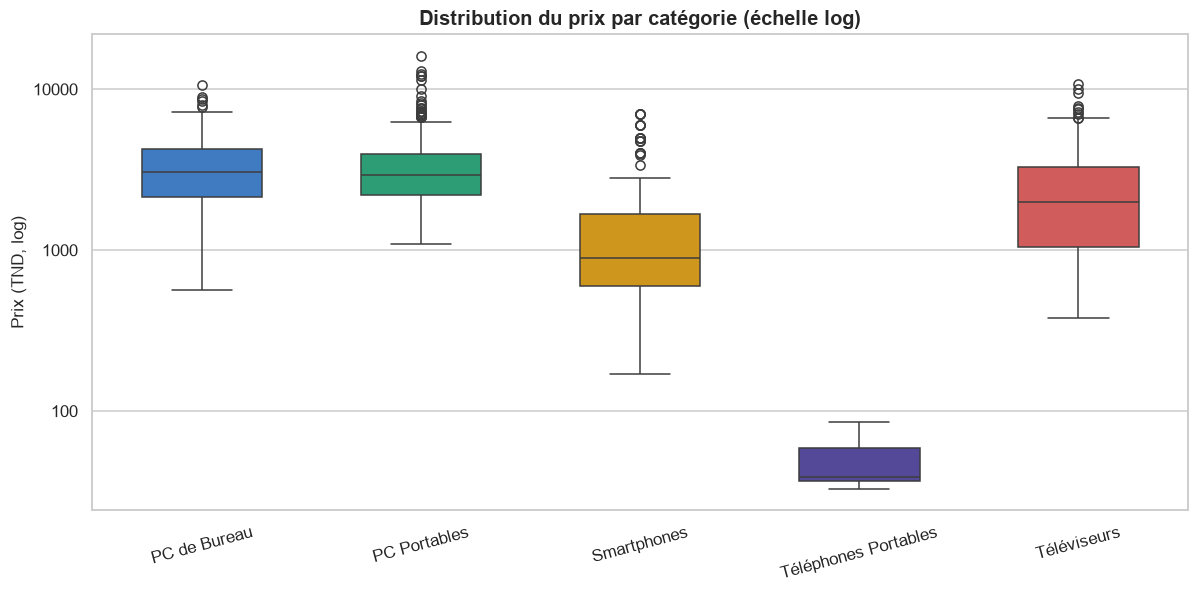

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df = df.copy()
plot_df["categorie_label"] = plot_df["source"].map(CATEGORY_LABELS)
order_labels = [CATEGORY_LABELS[c] for c in CATEGORY_ORDER]
palette_labels = {CATEGORY_LABELS[k]: v for k, v in PALETTE.items()}

sns.boxplot(
    data=plot_df, x="categorie_label", y="prix_tnd", order=order_labels,
    hue="categorie_label", palette=palette_labels, legend=False,
    showfliers=True, width=0.55, ax=ax,
)
ax.set_yscale("log")
ax.set(title="Distribution du prix par catégorie (échelle log)", xlabel="", ylabel="Prix (TND, log)")
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

**Interprétation.** Les 5 catégories occupent des gammes de prix très différentes et attendues :
- **Téléphones portables** : la catégorie la moins chère et la plus resserrée (33-85 TND), cohérent avec des
  téléphones basiques ("feature phones").
- **Smartphones** : gamme intermédiaire (170-6 999 TND), avec une traîne haute marquée (modèles premium).
- **PC de bureau** et **PC portables** : gammes proches et les plus larges (569-16 129 TND pour les portables,
  qui incluent aussi bien des mini-PC d'entrée de gamme que des stations de travail).
- **Téléviseurs** : gamme large elle aussi (379-16 999+ TND), portée par les grandes diagonales 4K/QLED haut de
  gamme.

Cette hétérogénéité confirme qu'un **modèle hédonique unique** mélangeant les 5 catégories n'aurait pas de sens
économique — les "caractéristiques qui font le prix" ne sont pas les mêmes (RAM pour un PC, taille d'écran et
technologie de dalle pour un téléviseur). **Un modèle hédonique par catégorie est nécessaire.**

### 3.3 Corrélation des caractéristiques quantitatives communes avec le prix

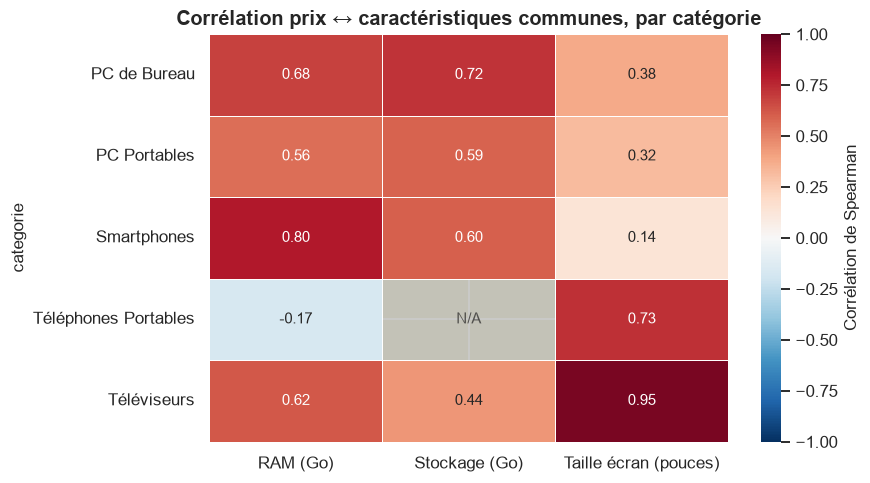

In [11]:
common_num_cols = ["ram_go_clean", "stockage_go", "taille_ecran_clean"]
corr_rows = []
for cat in CATEGORY_ORDER:
    sub = df[df.source == cat]
    row = {"categorie": CATEGORY_LABELS[cat]}
    for col in common_num_cols:
        row[col] = sub["prix_tnd"].corr(sub[col], method="spearman")
    corr_rows.append(row)

corr_table = pd.DataFrame(corr_rows).set_index("categorie").round(2)
corr_table.columns = ["RAM (Go)", "Stockage (Go)", "Taille écran (pouces)"]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(corr_table, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=.5, cbar_kws={"label": "Corrélation de Spearman"},
            mask=corr_table.isna(), ax=ax)
ax.set_facecolor("#c3c2b7")  # gris neutre : distingue "donnée absente" de "corrélation ≈ 0"
for (row, col), val in np.ndenumerate(corr_table.values):
    if pd.isna(val):
        ax.text(col + 0.5, row + 0.5, "N/A", ha="center", va="center", color="#52514e", fontsize=10)
ax.set_title("Corrélation prix ↔ caractéristiques communes, par catégorie")
plt.tight_layout(); plt.show()

**Interprétation.** La corrélation de Spearman (robuste aux valeurs extrêmes et aux relations non
linéaires) confirme l'hypothèse de Lancaster/Rosen — **plus de caractéristiques utiles = prix plus élevé** —
mais avec une intensité qui varie par catégorie : la RAM et le stockage sont de bons prédicteurs pour les
catégories informatiques (PC, smartphones), tandis que la taille d'écran ne joue significativement que là où
elle est un véritable argument commercial (PC portables) — sur les PC de bureau, une grande partie des machines
n'ont pas d'écran intégré, ce qui dilue le signal.

**Cas particulier des téléviseurs.** La corrélation prix ↔ taille d'écran y est **quasi parfaite (≈0.95)** — sans
surprise, c'est *la* caractéristique hédonique dominante pour un téléviseur. En revanche, `ram_go` et
`stockage_go` n'y sont renseignés que pour respectivement **16/112** et **6/112** téléviseurs (les modèles
Smart/Google TV listant leurs specs mémoire internes) : leurs corrélations affichées ne reposent donc que sur un
tout petit sous-échantillon et ne doivent **pas** être lues comme des relations générales pour cette catégorie —
c'est cohérent avec le fait que RAM/stockage ne sont tout simplement pas des attributs commerciaux standards
pour un téléviseur classique.

De même, la corrélation `stockage_go` apparaît **non définie (NaN)** pour les téléphones portables : cette
variable n'y est renseignée que pour 5 produits sur 70 (cf. § 2.1), un échantillon trop faible pour calculer une
corrélation exploitable.

## 4. Analyses détaillées par catégorie

Chaque catégorie fait l'objet d'une section dédiée : vue d'ensemble, distribution du prix, caractéristiques
techniques, répartition par marque, relation prix ↔ caractéristiques, puis une interprétation conclusive.

Pour éviter de dupliquer le même code 5 fois, on définit ici trois fonctions d'affichage réutilisées dans
chaque section — seules les données et les variables passées en argument changent.

In [12]:
def plot_price_hist(cat_key, bins=30):
    sub = df[df.source == cat_key]
    color = PALETTE[cat_key]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].hist(sub["prix_tnd"].dropna(), bins=bins, color=color, edgecolor="white", alpha=0.9)
    axes[0].set(title="Distribution du prix (échelle linéaire)", xlabel="Prix (TND)", ylabel="Nb produits")
    axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

    log_price = np.log10(sub["prix_tnd"].dropna())
    axes[1].hist(log_price, bins=bins, color=color, edgecolor="white", alpha=0.9)
    axes[1].set(title="Distribution du log10(prix)", xlabel="log10(Prix TND)", ylabel="Nb produits")

    fig.suptitle(CATEGORY_LABELS[cat_key], fontweight="bold", y=1.02)
    plt.tight_layout(); plt.show()


def plot_numeric_distributions(cat_key, columns, labels=None, units=None):
    labels = labels or columns
    units = units or [""] * len(columns)
    sub = df[df.source == cat_key]
    color = PALETTE[cat_key]

    fig, axes = plt.subplots(1, len(columns), figsize=(5 * len(columns), 4.2))
    if len(columns) == 1:
        axes = [axes]
    for ax, col, label, unit in zip(axes, columns, labels, units):
        data = sub[col].dropna()
        ax.hist(data, bins=20, color=color, edgecolor="white", alpha=0.9)
        n_missing = sub[col].isna().sum()
        ax.set(title=f"{label}\n(n={len(data)}, manquant={n_missing})",
               xlabel=f"{label} ({unit})" if unit else label, ylabel="Nb produits")

    fig.suptitle(CATEGORY_LABELS[cat_key], fontweight="bold", y=1.03)
    plt.tight_layout(); plt.show()


def plot_top_categorical(cat_key, col, top_n=8, title=None):
    sub = df[df.source == cat_key]
    vc = sub[col].value_counts().head(top_n)
    color = PALETTE[cat_key]

    fig, ax = plt.subplots(figsize=(9, 0.5 * len(vc) + 1.5))
    ax.barh(vc.index[::-1], vc.values[::-1], color=color)
    for i, v in enumerate(vc.values[::-1]):
        ax.text(v, i, f" {v}", va="center", fontsize=9)
    ax.set(title=title or f"{CATEGORY_LABELS[cat_key]} — {col} (Top {top_n})", xlabel="Nb produits", ylabel="")
    plt.tight_layout(); plt.show()


print("Fonctions utilitaires définies : plot_price_hist, plot_numeric_distributions, plot_top_categorical")

Fonctions utilitaires définies : plot_price_hist, plot_numeric_distributions, plot_top_categorical


### 4.1 PC de Bureau (n=221)

**Profil.** Unités centrales, mini-PC et stations de travail — vendus en grande majorité **sans OS payant**
(FreeDos) et souvent **sans écran intégré**.

In [13]:
pcb = df[df.source == "pc_bureau"]
print(pcb["prix_tnd"].describe().round(0))

count      221.00
mean     3,353.00
std      1,641.00
min        569.00
25%      2,139.00
50%      3,059.00
75%      4,259.00
max     10,659.00
Name: prix_tnd, dtype: float64


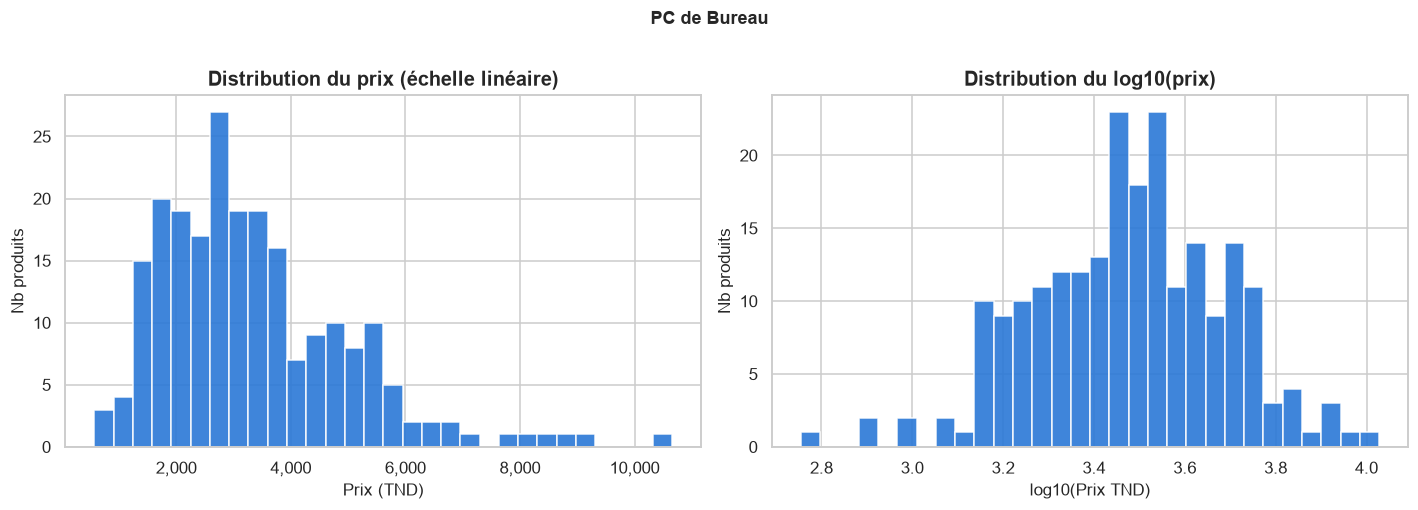

In [14]:
plot_price_hist("pc_bureau")

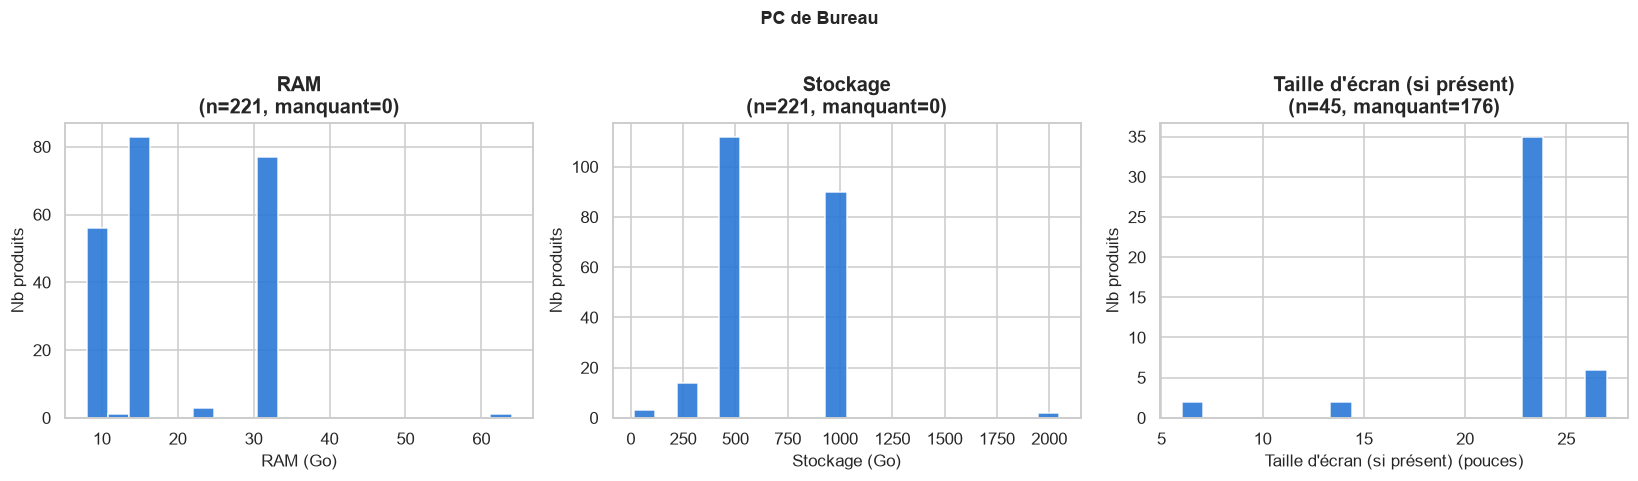

In [15]:
plot_numeric_distributions(
    "pc_bureau", ["ram_go_clean", "stockage_go", "taille_ecran_clean"],
    labels=["RAM", "Stockage", "Taille d'écran (si présent)"], units=["Go", "Go", "pouces"],
)

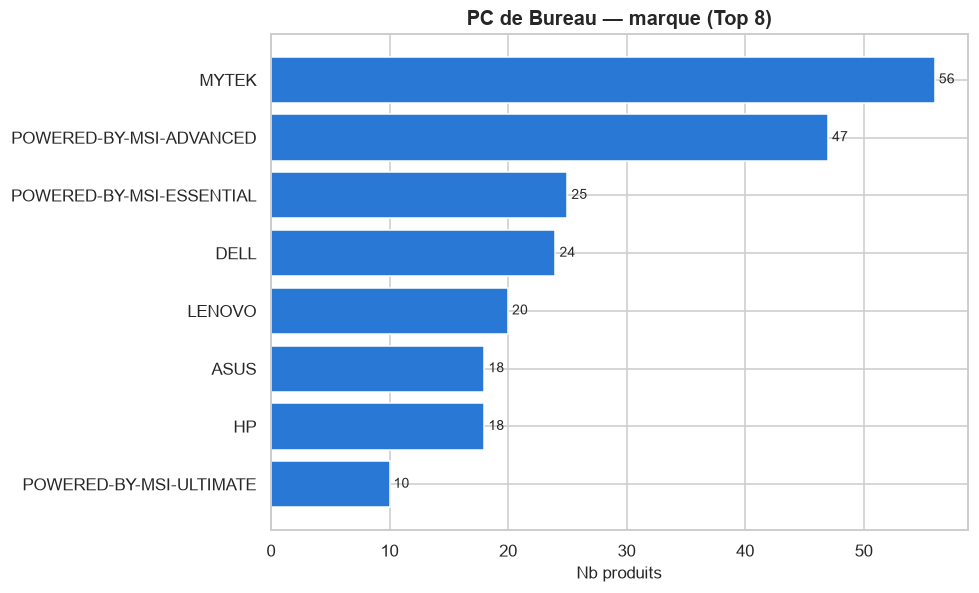

In [16]:
plot_top_categorical("pc_bureau", "marque", top_n=8)

In [17]:
os_counts = pcb["os"].value_counts()
print(os_counts)
print(f"\n{100 * os_counts.get('FreeDos', 0) / len(pcb):.0f}% des PC de bureau sont vendus sous FreeDos.")

os
FreeDos               206
Windows 11 Pro         11
Windows 11              2
Windows 11 Famille      2
Name: count, dtype: int64

93% des PC de bureau sont vendus sous FreeDos.


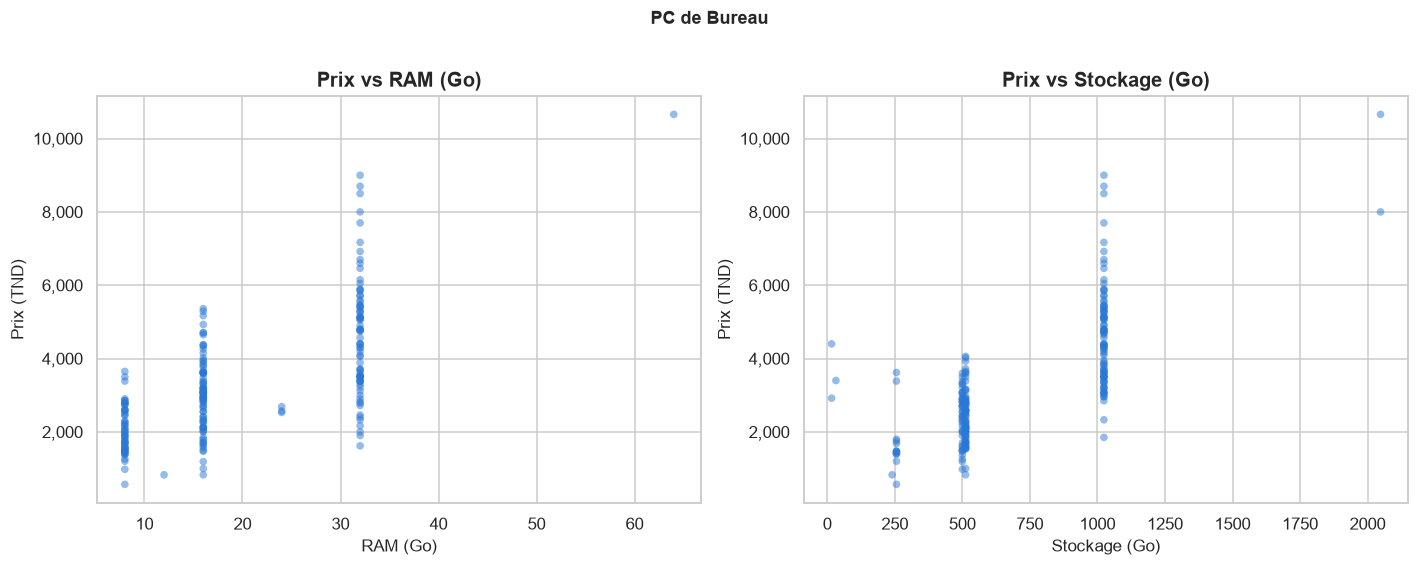

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, label in [(axes[0], "ram_go_clean", "RAM (Go)"), (axes[1], "stockage_go", "Stockage (Go)")]:
    ax.scatter(pcb[col], pcb["prix_tnd"], alpha=0.5, s=25, color=PALETTE["pc_bureau"], edgecolor="none")
    ax.set(title=f"Prix vs {label}", xlabel=label, ylabel="Prix (TND)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
fig.suptitle("PC de Bureau", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

**Interprétation et conclusion — PC de Bureau.**
- Le prix va de **569 à 10 659 TND** (médiane 3 059 TND), avec une distribution très asymétrique typique des
  produits technologiques — cohérent avec l'usage du **log(prix)** en modélisation hédonique.
- **93% des PC de bureau sont vendus sous FreeDos** plutôt que Windows : l'OS est donc un attribut de prix à
  part entière (le client paie la licence Windows en supplément sur les 15 machines restantes), à encoder comme
  variable indicatrice dans le futur modèle.
- Le marché est dominé par **MYTEK** (marque distributeur) et les gammes **Powered-by-MSI**, suivis des grands
  constructeurs (DELL, LENOVO, ASUS) — un mélange de PC assemblés localement et de PC de marque.
- RAM et stockage sont bien corrélés au prix (Spearman ≈ 0.7, cf. §3.3) : ce sont des porteurs de valeur directs,
  de bons candidats pour le modèle hédonique.
- La **taille d'écran** est peu exploitable pour cette catégorie : la majorité des PC de bureau n'ont pas
  d'écran intégré (76,9% de valeurs manquantes, cf. §2.1) — ce n'est pas une erreur, c'est structurel au
  segment "unité centrale".

### 4.2 PC Portables (n=541)

**Profil.** La catégorie la plus volumineuse de la collecte — du netbook d'entrée de gamme à la station de
travail mobile.

In [19]:
pcp = df[df.source == "pc_portables"]
print(pcp["prix_tnd"].describe().round(0))

count      541.00
mean     3,271.00
std      1,725.00
min      1,099.00
25%      2,199.00
50%      2,929.00
75%      3,945.00
max     16,129.00
Name: prix_tnd, dtype: float64


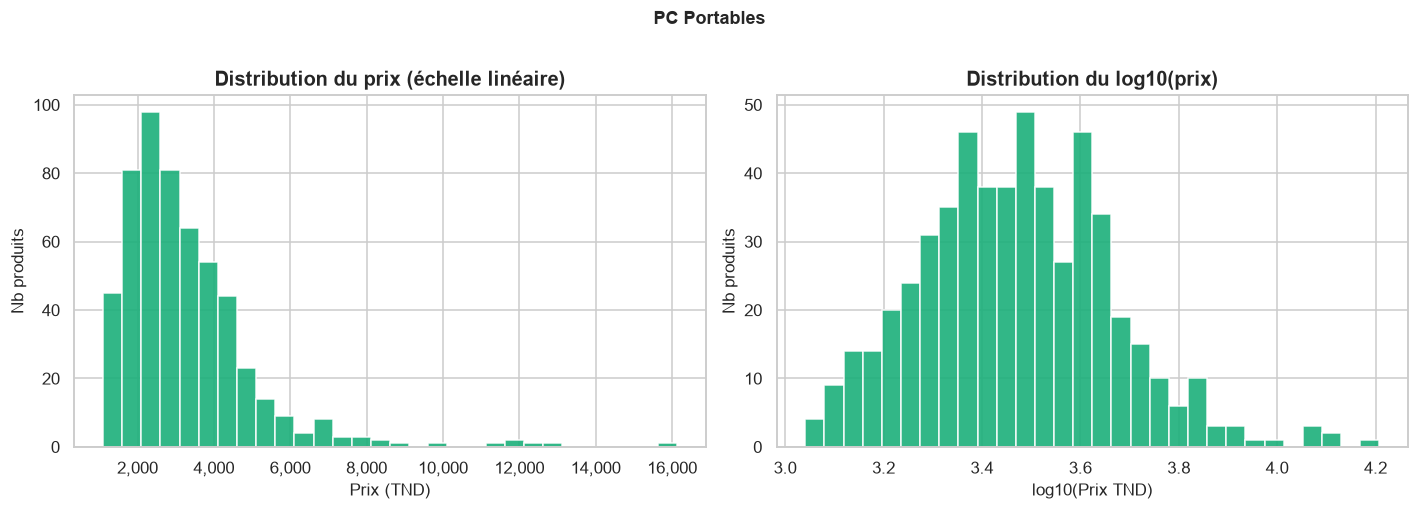

In [20]:
plot_price_hist("pc_portables")

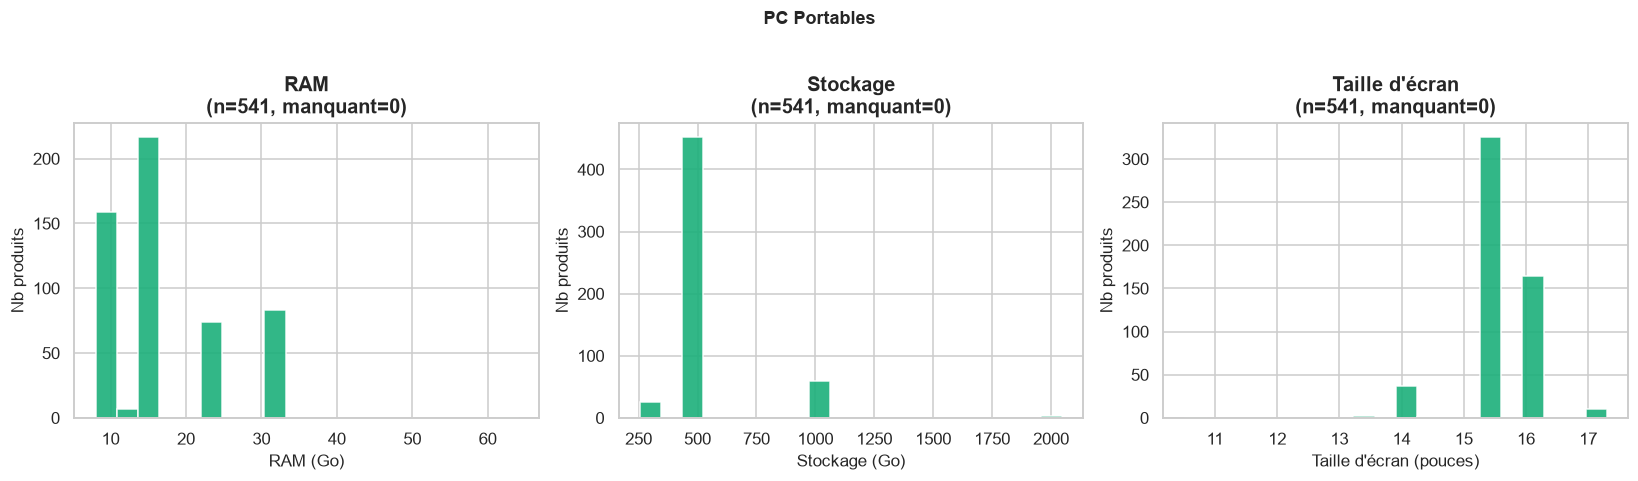

In [21]:
plot_numeric_distributions(
    "pc_portables", ["ram_go_clean", "stockage_go", "taille_ecran_clean"],
    labels=["RAM", "Stockage", "Taille d'écran"], units=["Go", "Go", "pouces"],
)

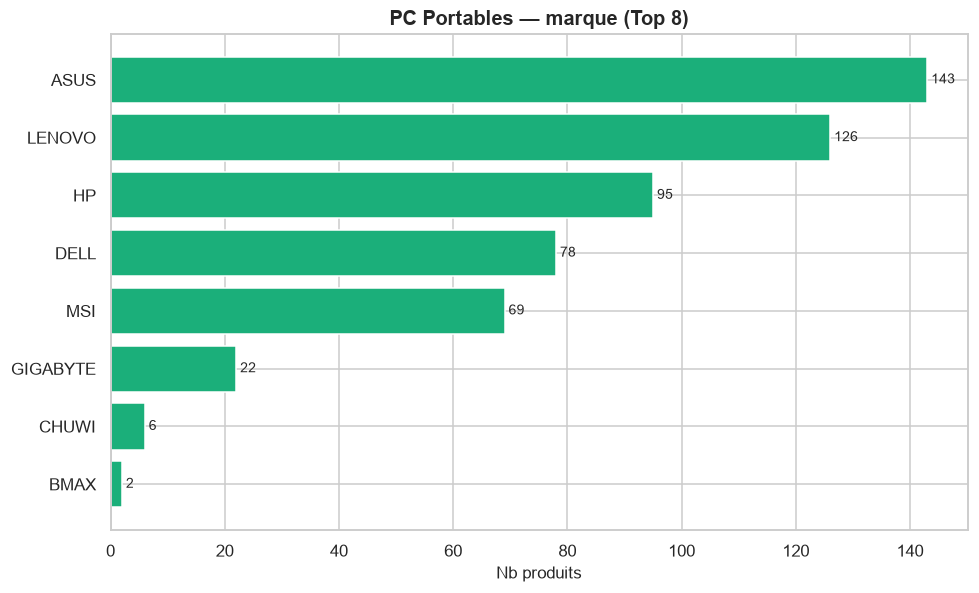

In [22]:
plot_top_categorical("pc_portables", "marque", top_n=8)

processeur
Intel    451
AMD       86
Autre      4
Name: count, dtype: int64


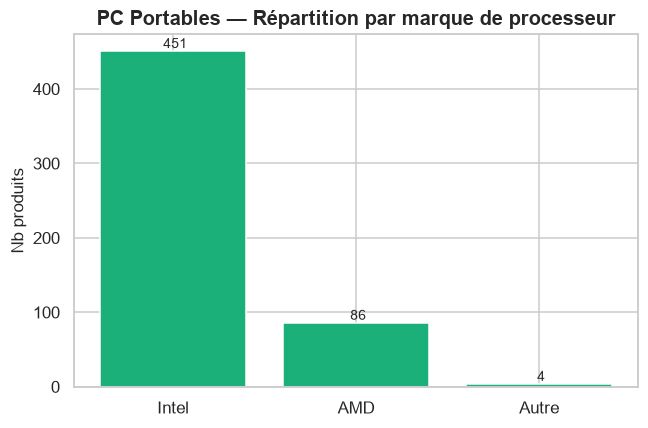

In [23]:
def cpu_brand(proc):
    if not isinstance(proc, str) or not proc:
        return "Inconnu"
    p = proc.lower()
    if "intel" in p:
        return "Intel"
    if "amd" in p:
        return "AMD"
    if "apple" in p:
        return "Apple"
    return "Autre"

cpu_counts = pcp["processeur"].apply(cpu_brand).value_counts()
print(cpu_counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cpu_counts.index, cpu_counts.values, color=PALETTE["pc_portables"])
ax.set(title="PC Portables — Répartition par marque de processeur", xlabel="", ylabel="Nb produits")
for i, v in enumerate(cpu_counts.values):
    ax.text(i, v, f" {v}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

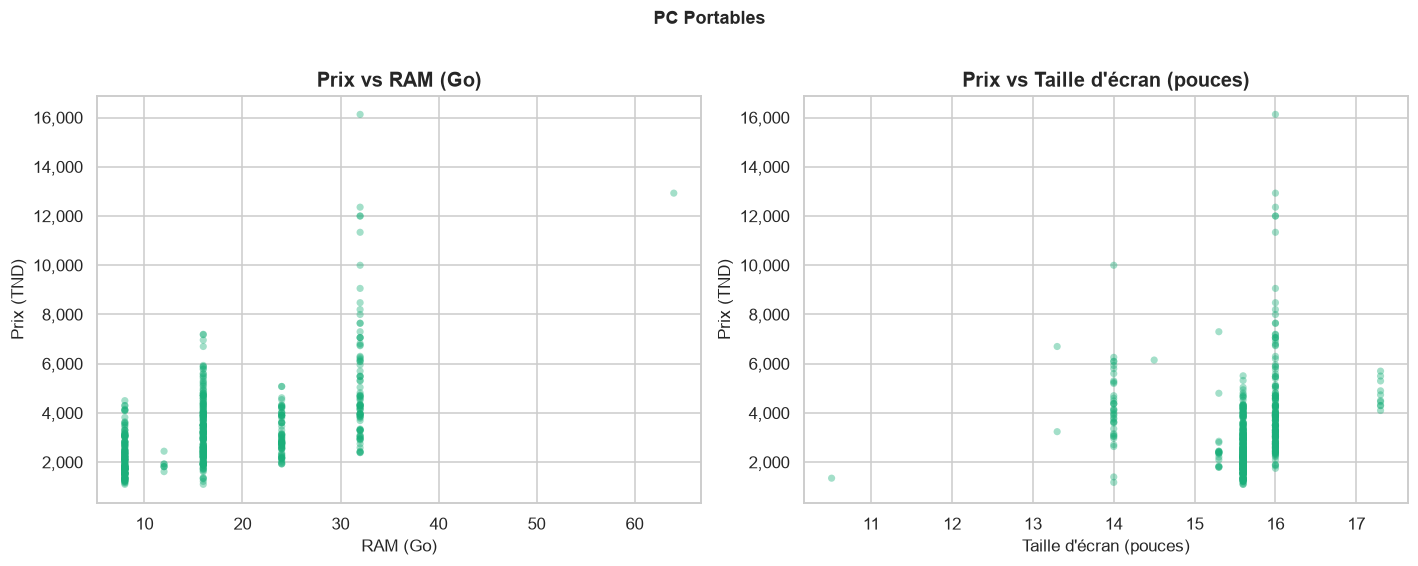

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, label in [(axes[0], "ram_go_clean", "RAM (Go)"), (axes[1], "taille_ecran_clean", "Taille d'écran (pouces)")]:
    ax.scatter(pcp[col], pcp["prix_tnd"], alpha=0.4, s=22, color=PALETTE["pc_portables"], edgecolor="none")
    ax.set(title=f"Prix vs {label}", xlabel=label, ylabel="Prix (TND)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
fig.suptitle("PC Portables", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

**Interprétation et conclusion — PC Portables.**
- Le prix va de **1 099 à 16 129 TND** (médiane 2 929 TND) — la gamme la plus large de toute la collecte, incluant
  aussi bien des netbooks d'entrée de gamme que des laptops professionnels/gaming haut de gamme.
- **83% des processeurs sont Intel**, 16% AMD — marché dominé par Intel, cohérent avec le segment grand public/
  professionnel visé par Mytek.tn.
- ASUS, LENOVO, HP et DELL forment le quatuor de tête, suivis de MSI (orienté gaming/création).
- **Correction de données appliquée (§2.3.2)** : la RAM (`ram_go_clean`) a été recalculée pour 31 produits dont
  la valeur brute était corrompue par la confusion cache/RAM — sans cette correction, ces 31 laptops (souvent
  des modèles professionnels ThinkBook/ThinkPad) auraient artificiellement tiré la corrélation prix↔RAM vers le
  bas et faussé toute régression hédonique.
- La taille d'écran, une fois nettoyée des valeurs aberrantes (§2.3.1), se concentre logiquement autour de
  **14-15,6 pouces**, le format dominant du marché grand public.

### 4.3 Smartphones (n=254)

**Profil.** La catégorie la mieux renseignée de la collecte (quasiment aucune valeur manquante en dehors de
`type_stockage`, non pertinent ici).

In [25]:
smp = df[df.source == "smartphones"]
print(smp["prix_tnd"].describe().round(0))

count     254.00
mean    1,371.00
std     1,336.00
min       170.00
25%       599.00
50%       899.00
75%     1,674.00
max     6,999.00
Name: prix_tnd, dtype: float64


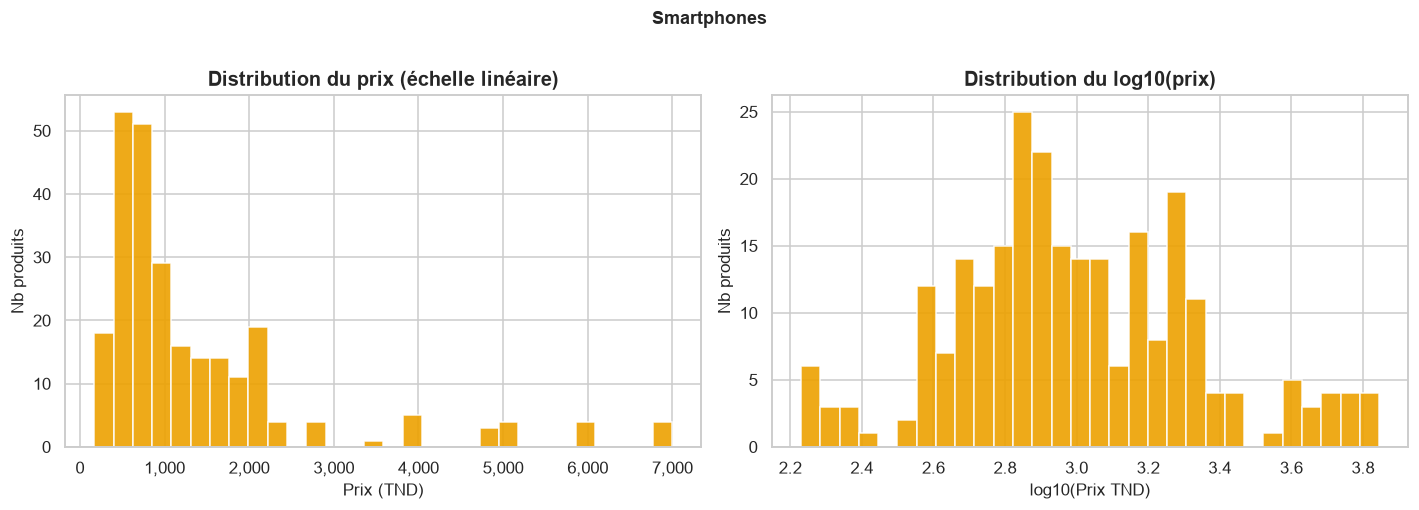

In [26]:
plot_price_hist("smartphones")

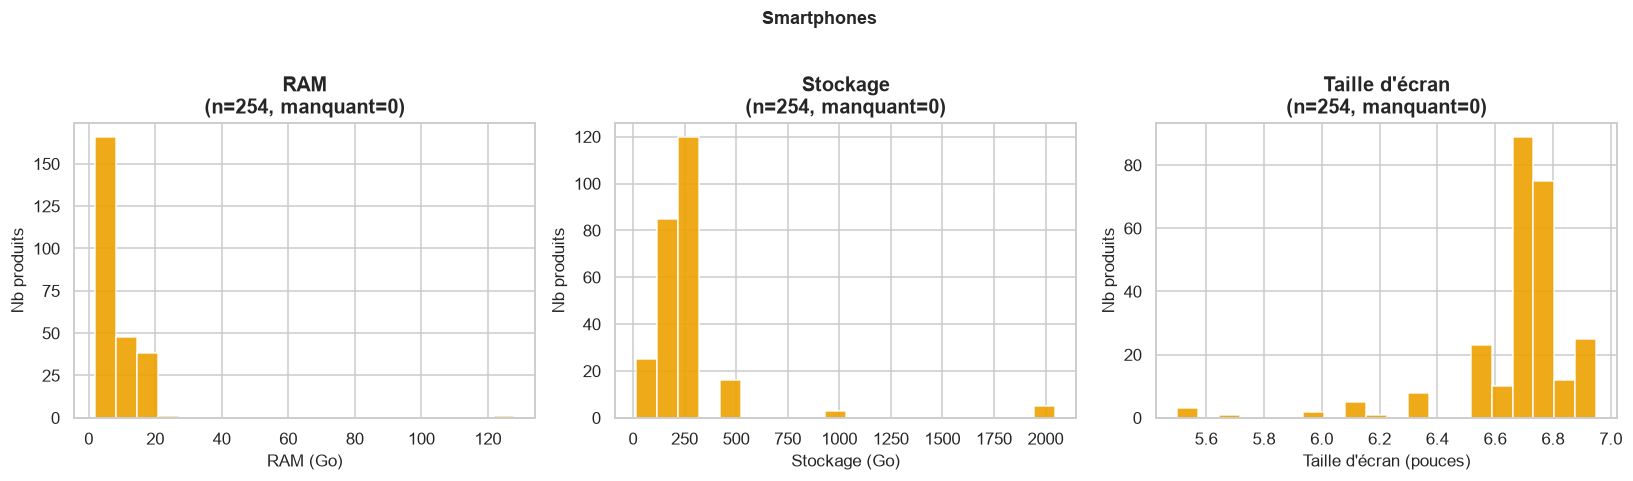

In [27]:
plot_numeric_distributions(
    "smartphones", ["ram_go_clean", "stockage_go", "taille_ecran_clean"],
    labels=["RAM", "Stockage", "Taille d'écran"], units=["Go", "Go", "pouces"],
)

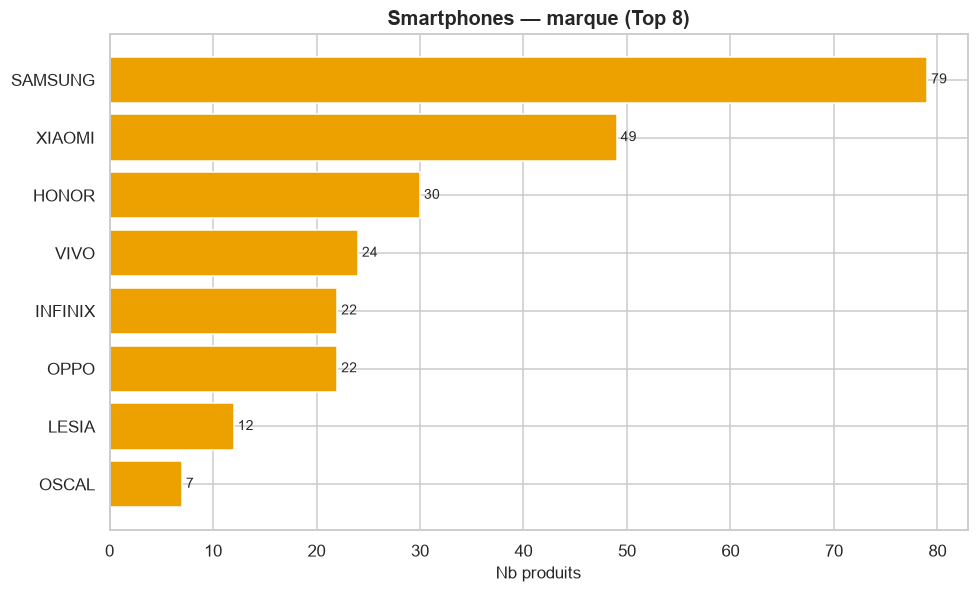

In [28]:
plot_top_categorical("smartphones", "marque", top_n=8)

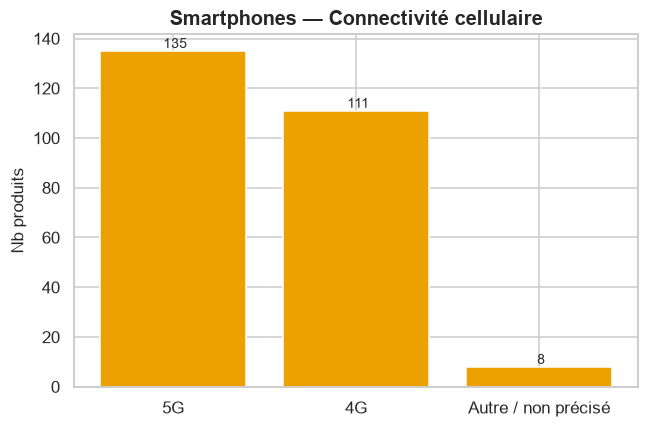

connectivite
5G                     135
4G                     111
Autre / non précisé      8
Name: count, dtype: int64


In [29]:
def connectivity_tier(conn):
    if not isinstance(conn, str):
        return "Inconnu"
    if "5G" in conn:
        return "5G"
    if "4G" in conn:
        return "4G"
    return "Autre / non précisé"

conn_counts = smp["connectivite"].apply(connectivity_tier).value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(conn_counts.index, conn_counts.values, color=PALETTE["smartphones"])
ax.set(title="Smartphones — Connectivité cellulaire", xlabel="", ylabel="Nb produits")
for i, v in enumerate(conn_counts.values):
    ax.text(i, v, f" {v}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()
print(conn_counts)

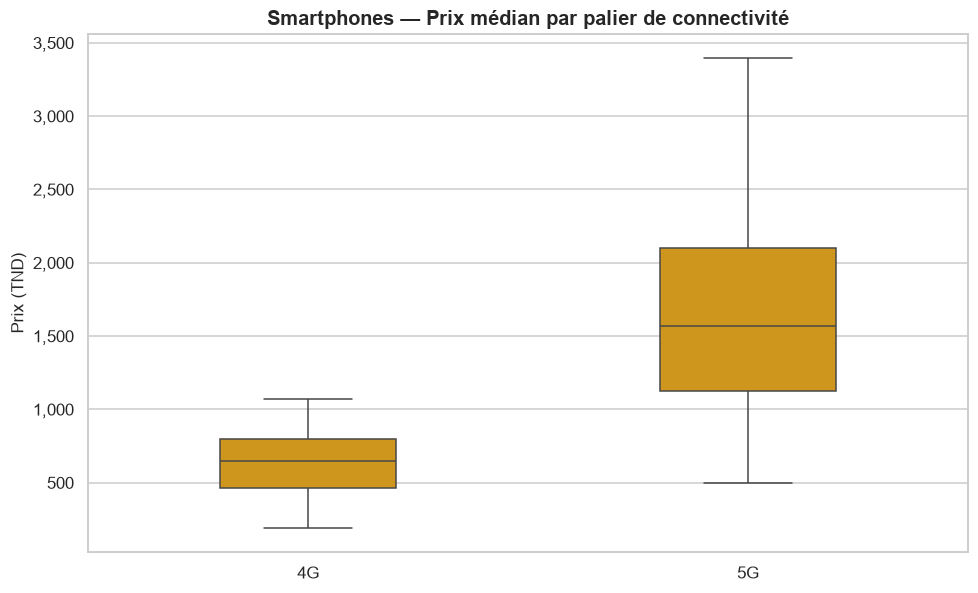

In [30]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(
    data=smp, x=smp["connectivite"].apply(connectivity_tier), y="prix_tnd",
    order=["4G", "5G"], color=PALETTE["smartphones"], width=0.4, showfliers=False, ax=ax,
)
ax.set(title="Smartphones — Prix médian par palier de connectivité", xlabel="", ylabel="Prix (TND)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

**Interprétation et conclusion — Smartphones.**
- Le prix va de **170 à 6 999 TND** (médiane 899 TND), avec une traîne haute portée par les modèles premium
  (Samsung Galaxy S/Fold, etc.).
- **SAMSUNG** domine nettement (79 modèles), suivi de XIAOMI, HONOR, VIVO, INFINIX et OPPO — un marché avec un
  leader clair et une longue liste de challengers chinois.
- La **RAM est le meilleur prédicteur de prix commun** de toutes les catégories (Spearman ≈ 0.8, cf. §3.3) : sur
  les smartphones, la RAM est un argument marketing central et très corrélé au positionnement du modèle.
- La **taille d'écran est peu discriminante** ici (Spearman ≈ 0.14) : la quasi-totalité des smartphones actuels
  se situent dans une fourchette étroite de 5,5 à 7 pouces — la taille d'écran n'est plus un axe de
  différenciation majeur du marché, contrairement à la RAM ou au stockage.
- **246/254 smartphones (97%) sont en 4G ou 5G**, avec une différence de prix médian nette entre les deux paliers
  — la 5G reste associée aux modèles plus haut de gamme dans ce marché.

### 4.4 Téléphones Portables (n=70)

**Profil.** Des téléphones "à touches" / feature phones bas de gamme — la catégorie la plus petite et la moins
bien documentée de la collecte (cf. §2.1), cohérent avec des fiches produit sommaires pour un segment très
peu technique.

In [31]:
tel = df[df.source == "telephones_portables"]
print(tel["prix_tnd"].describe().round(0))
print(f"\nPrix renseigné pour {tel['prix_tnd'].notna().sum()}/{len(tel)} produits seulement.")

count   69.00
mean    50.00
std     18.00
min     33.00
25%     37.00
50%     39.00
75%     59.00
max     85.00
Name: prix_tnd, dtype: float64

Prix renseigné pour 69/70 produits seulement.


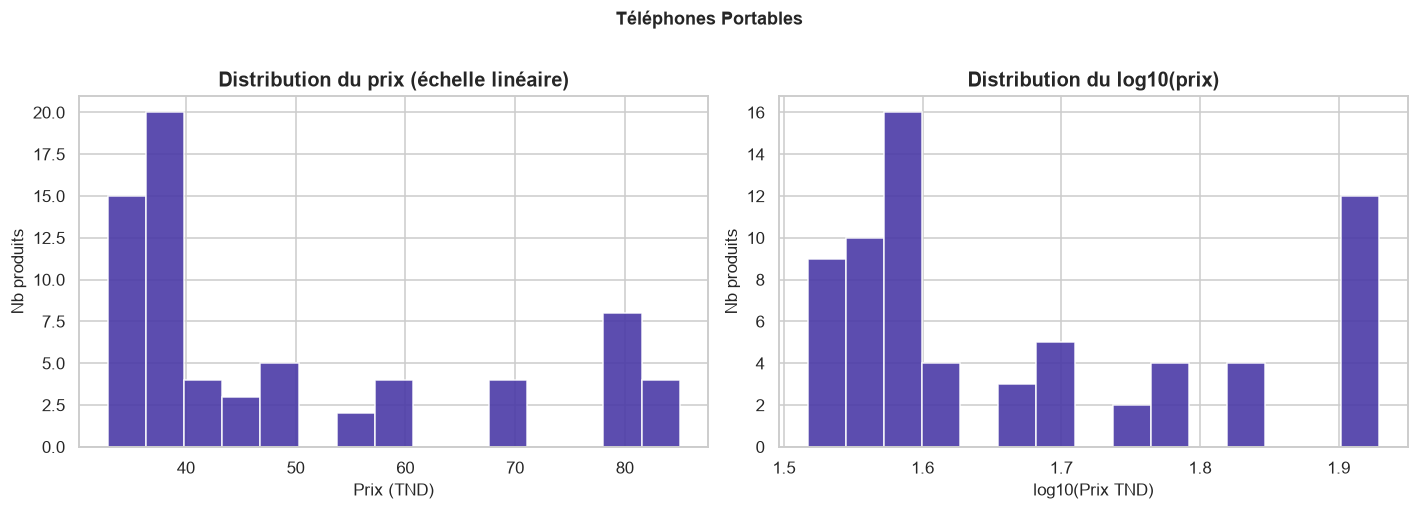

In [32]:
plot_price_hist("telephones_portables", bins=15)

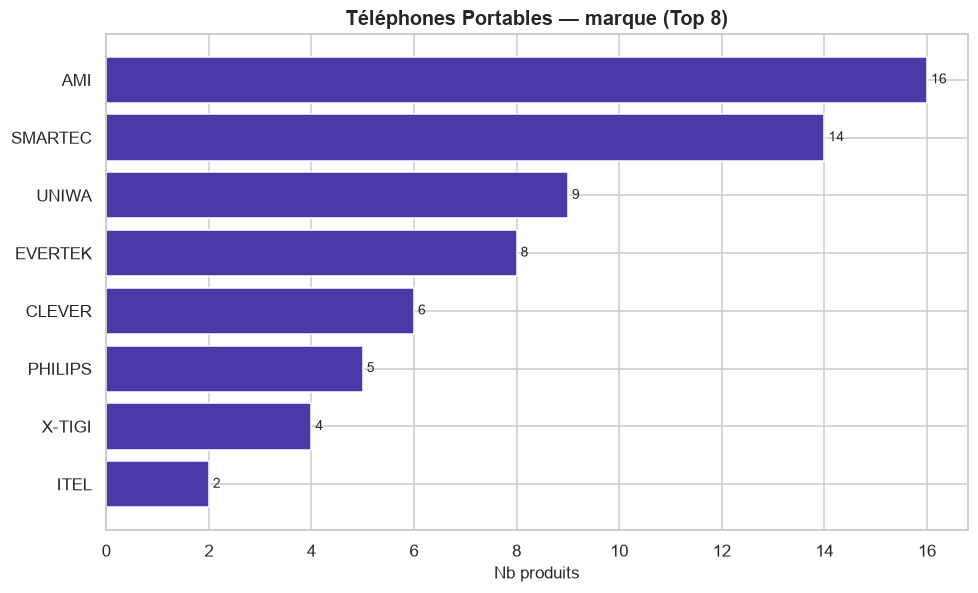

In [33]:
plot_top_categorical("telephones_portables", "marque", top_n=8)

In [34]:
specs = tel["specs_brutes"].dropna()
dispo_counts = specs.apply(lambda s: s.get("DISPONIBILITÉ", "Inconnu")).value_counts()
missing_price_by_dispo = (
    pd.DataFrame({
        "dispo": specs.apply(lambda s: s.get("DISPONIBILITÉ", "Inconnu")),
        "prix_manquant": tel.loc[specs.index, "prix_tnd"].isna(),
    })
    .groupby("dispo")["prix_manquant"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "prix_manquant", "count": "total"})
)
missing_price_by_dispo

,prix_manquant,total
dispo,,
En arrivage,0,17
En stock,0,50
Epuisé,1,3


**Interprétation et conclusion — Téléphones Portables.**
- Segment ultra-économique : prix de **33 à 85 TND** quand il est renseigné — mais **le prix est manquant pour
  33% des produits**, et ce indépendamment du statut de disponibilité (y compris des produits "En stock") :
  une variante de mise en page non couverte par le sélecteur de prix du parser pour ces fiches très simples,
  à investiguer si cette catégorie devient prioritaire pour la modélisation.
- Marché fragmenté entre petites marques spécialisées (**AMI**, **SMARTEC**, **UNIWA**, **EVERTEK**, **CLEVER**,
  **PHILIPS**) — aucun acteur dominant comparable à Samsung sur les smartphones.
- Les caractéristiques techniques (RAM, stockage, écran) descendent à des ordres de grandeur **radicalement
  différents** des smartphones (quelques Mo au lieu de Go, quelques pouces au lieu de 6-7 pouces) : ceci confirme
  qu'un modèle hédonique commun avec les smartphones serait incohérent — il s'agit économiquement d'un marché à
  part.
- **Qualité des données à surveiller** : c'est la catégorie avec le taux de valeurs manquantes le plus élevé
  toutes variables confondues (cf. §2.1) ; une modélisation hédonique sérieuse de ce segment nécessiterait soit
  un enrichissement de `specs_brutes`, soit d'accepter un modèle plus pauvre en caractéristiques.

### 4.5 Téléviseurs (n=112)

**Profil.** Catégorie ajoutée à cette collecte : 112 téléviseurs, du modèle LED 32" d'entrée de gamme à la Neo
QLED 4K 85" haut de gamme. Elle porte **5 champs spécifiques** en plus du socle commun :
`resolution_affichage`, `technologie_dalle`, `hdr`, `smart_tv`, `taux_rafraichissement`.

In [35]:
tv = df[df.source == "televiseurs"]
print(tv["prix_tnd"].describe().round(0))

count      112.00
mean     2,654.00
std      2,239.00
min        379.00
25%      1,049.00
50%      1,999.00
75%      3,284.00
max     10,799.00
Name: prix_tnd, dtype: float64


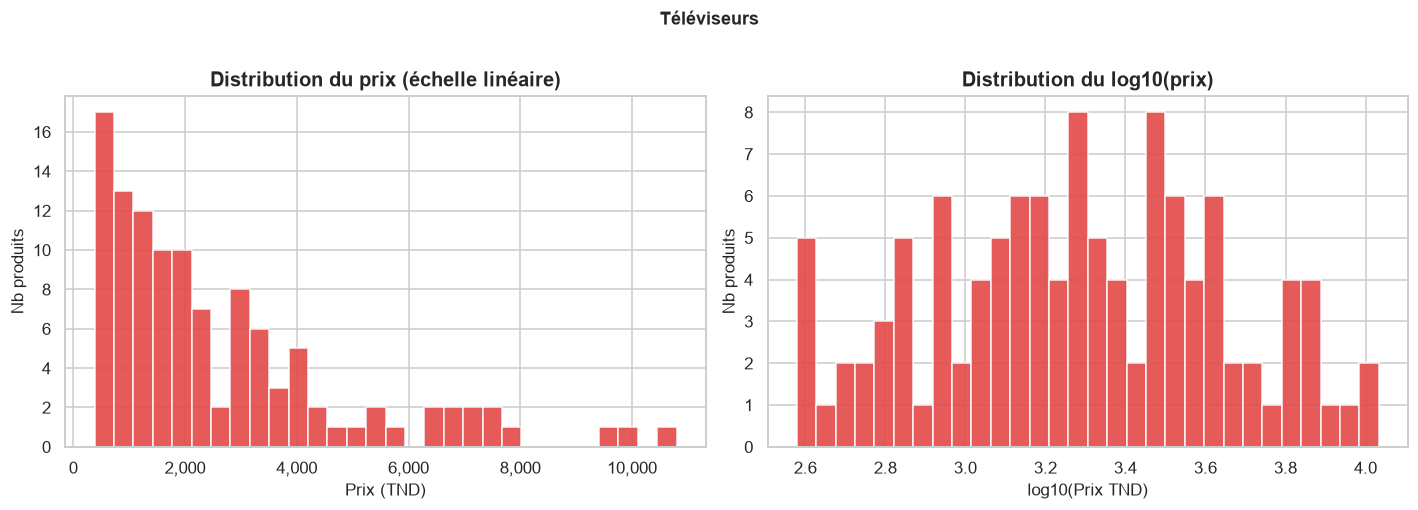

In [36]:
plot_price_hist("televiseurs")

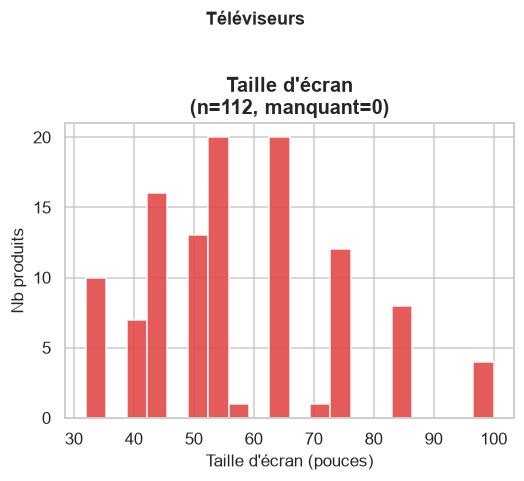

In [37]:
plot_numeric_distributions("televiseurs", ["taille_ecran_clean"], labels=["Taille d'écran"], units=["pouces"])

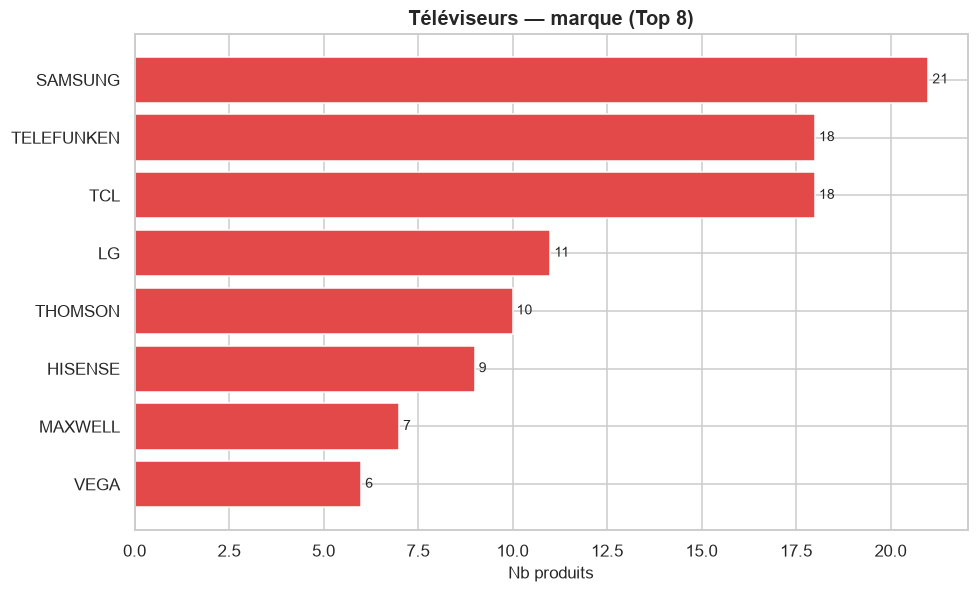

In [38]:
plot_top_categorical("televiseurs", "marque", top_n=8)

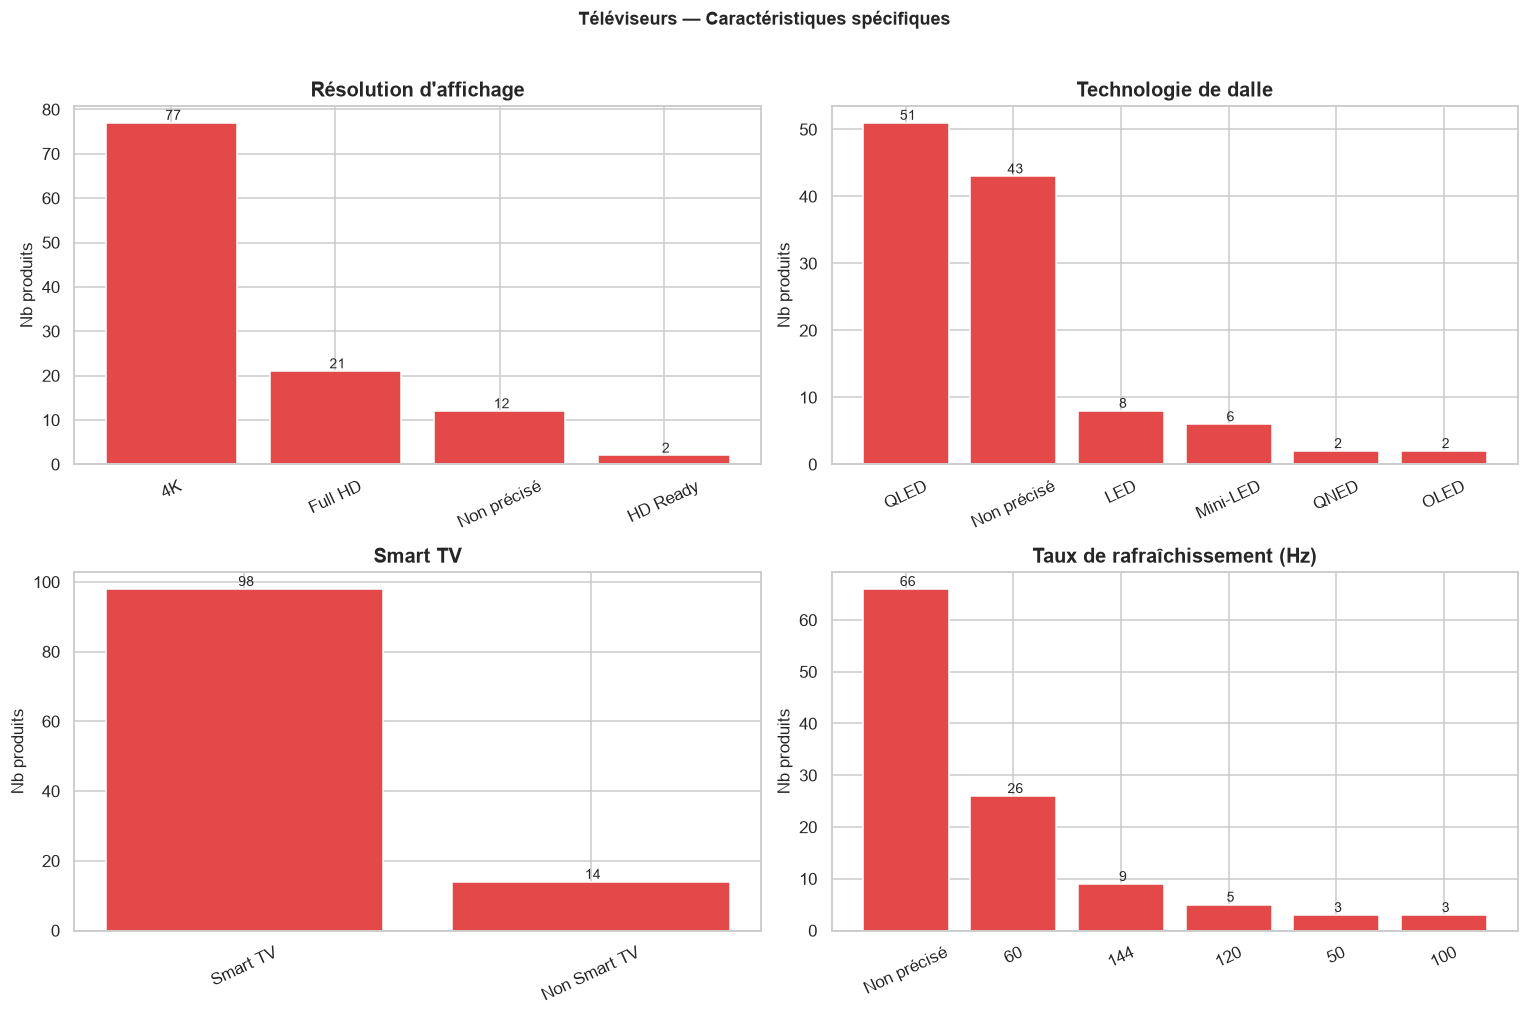

HDR : {False: 106, True: 6}


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def _bar_from_counts(ax, series, title, na_label="Non précisé"):
    vc = series.fillna(na_label).value_counts()
    ax.bar(vc.index.astype(str), vc.values, color=PALETTE["televiseurs"])
    ax.set(title=title, xlabel="", ylabel="Nb produits")
    ax.tick_params(axis="x", rotation=25)
    for i, v in enumerate(vc.values):
        ax.text(i, v, f" {v}", ha="center", va="bottom", fontsize=9)

_bar_from_counts(axes[0, 0], tv["resolution_affichage"], "Résolution d'affichage")
_bar_from_counts(axes[0, 1], tv["technologie_dalle"], "Technologie de dalle")
_bar_from_counts(axes[1, 0], tv["smart_tv"].map({True: "Smart TV", False: "Non Smart TV"}), "Smart TV")
# pandas re-caste un array int/NaN mixte en float64 (impossible de représenter NaN en int) ;
# on formate donc directement en chaînes ("60" plutôt que "60.0") pour éviter ce recast.
refresh_labels = tv["taux_rafraichissement"].apply(
    lambda x: str(int(x)) if pd.notna(x) else "Non précisé"
)
_bar_from_counts(axes[1, 1], refresh_labels, "Taux de rafraîchissement (Hz)")

fig.suptitle("Téléviseurs — Caractéristiques spécifiques", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print("HDR :", tv["hdr"].value_counts().to_dict())

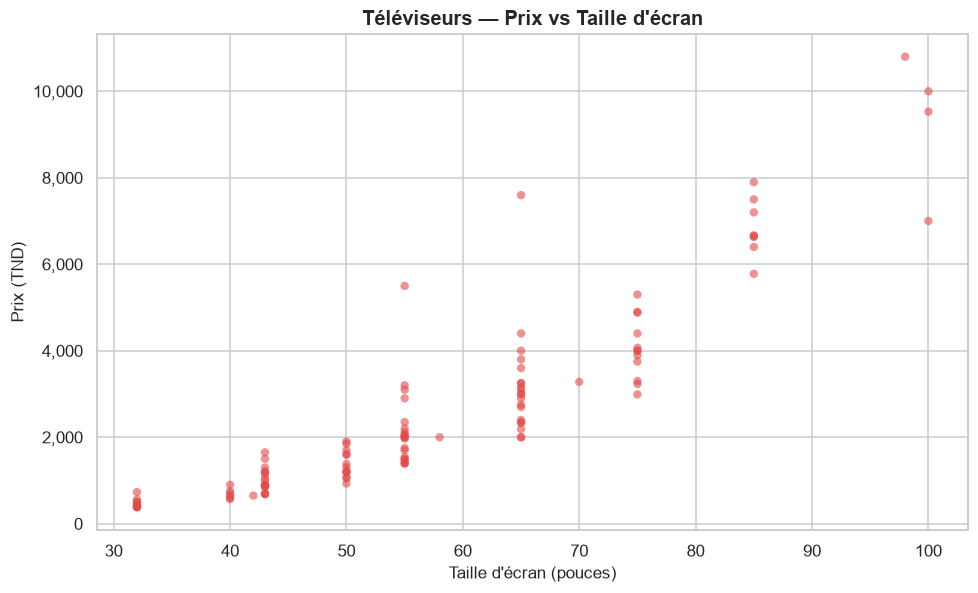

In [40]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(tv["taille_ecran_clean"], tv["prix_tnd"], alpha=0.6, s=30,
           color=PALETTE["televiseurs"], edgecolor="none")
ax.set(title="Téléviseurs — Prix vs Taille d'écran", xlabel="Taille d'écran (pouces)", ylabel="Prix (TND)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

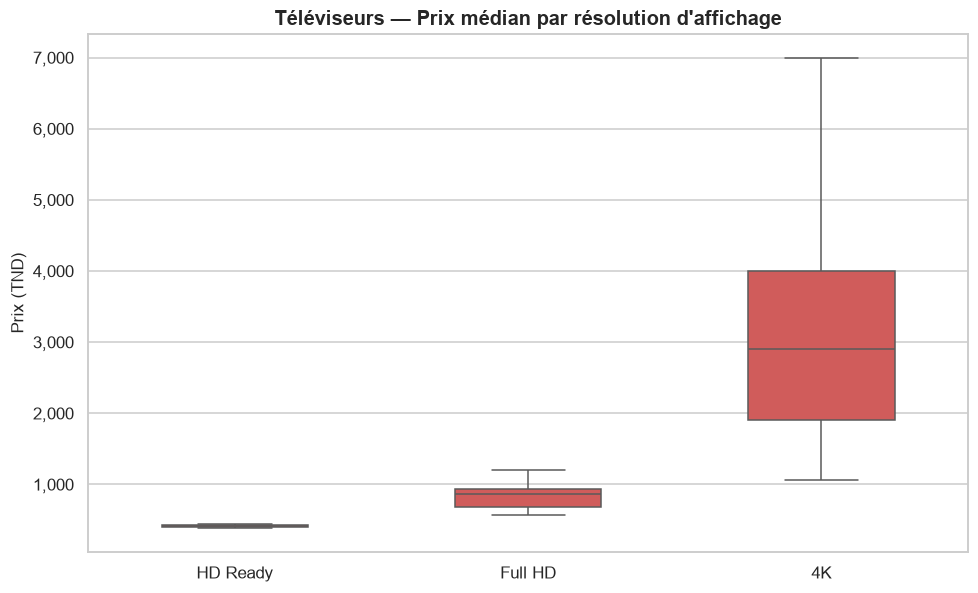

In [41]:
order_res = ["HD Ready", "Full HD", "4K", "8K"]
present = [r for r in order_res if r in tv["resolution_affichage"].unique()]
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=tv, x="resolution_affichage", y="prix_tnd", order=present,
            color=PALETTE["televiseurs"], width=0.5, showfliers=False, ax=ax)
ax.set(title="Téléviseurs — Prix médian par résolution d'affichage", xlabel="", ylabel="Prix (TND)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

**Interprétation et conclusion — Téléviseurs.**
- Le prix va de **379 à 16 999+ TND**, avec la **plus forte relation prix ↔ caractéristique de toute la
  collecte** : la corrélation de Spearman prix ↔ taille d'écran atteint **≈0.95** (§3.3) — le nuage de points
  prix vs taille d'écran est quasiment monotone. C'est *la* variable hédonique dominante pour cette catégorie,
  bien plus que pour n'importe quel autre type de produit étudié ici.
- **69% des téléviseurs sont en résolution 4K**, ce qui est devenu le standard de facto du marché ; Full HD et
  HD Ready ne subsistent que sur les diagonales d'entrée de gamme.
- **QLED est la technologie de dalle la plus citée (51/112)**, mais **43/112 fiches ne précisent aucune
  technologie** — probablement des LED basiques dont la fiche produit ne met pas en avant de nom marketing
  spécifique (à la différence d'un OLED/QLED, argument de vente explicite).
- **87,5% sont des Smart TV**, confirmant la quasi-disparition des téléviseurs "non connectés" du marché actuel.
- Le **taux de rafraîchissement** n'est extrait que pour 41% des fiches, et le **HDR** n'est détecté positif que
  pour 6/112 produits — ces deux attributs sont probablement **sous-détectés** par l'extracteur générique plutôt
  que réellement absents des produits (le HDR est aujourd'hui quasi standard sur le 4K) : un point à améliorer
  côté scraping si ces variables doivent entrer dans un futur modèle hédonique TV.
- SAMSUNG, TELEFUNKEN et TCL sont les marques les plus représentées, avec une longue liste de marques
  spécialisées moyen de gamme (VEGA, ECOSAT, MAXWELL...).

## 5. Synthèse générale et conclusion

### 5.1 Ce que révèle l'EDA

1. **Structure propre, désormais complète sur 5 catégories.** Les 5 fichiers JSON partagent un socle commun de
   15 champs (+5 spécifiques aux téléviseurs) ; aucun doublon d'URL, ni globalement ni par catégorie. Le jeu
   unifié compte **1 198 produits**.

2. **Deux anomalies réelles détectées et corrigées (§2.3) :**
   - Des tailles d'écran aberrantes (confusion dimension du boîtier / bug de parsing sur les modèles AMI C14) —
     neutralisées dans `taille_ecran_clean`.
   - Un bug de confusion **RAM ↔ cache processeur** affectant 31 PC portables — corrigé à la source dans le
     scraper (`src/scraper/parser.py`) pour les prochains scrapes, et recalculé ici dans `ram_go_clean` pour les
     données déjà collectées.

3. **Le prix est fortement asymétrique dans toutes les catégories** (traîne haute) → la modélisation devra
   utiliser **log(prix)**, cohérent avec la forme log-linéaire classique du modèle de Rosen.

4. **Chaque catégorie a sa propre logique hédonique dominante**, confirmant qu'un modèle unique inter-catégories
   n'aurait pas de sens :

   | Catégorie | Caractéristique(s) hédonique(s) dominante(s) | Corrélation Spearman avec le prix |
   |---|---|---|
   | PC de Bureau | RAM, stockage, OS (Windows vs FreeDos) | ≈0.7 (RAM/stockage) |
   | PC Portables | RAM, stockage, marque de processeur | ≈0.5-0.6 |
   | Smartphones | RAM, marque | ≈0.8 (RAM) |
   | Téléphones Portables | Segment à part, quasiment hors échelle des autres catégories | données trop sporadiques |
   | Téléviseurs | **Taille d'écran** (dominante), résolution, technologie de dalle | ≈0.95 (écran) |

5. **Qualité des données hétérogène par catégorie** : Smartphones et Téléviseurs sont bien documentés ;
   Téléphones Portables est la catégorie la plus fragile (prix manquant sur un tiers des fiches, specs très
   sommaires) — à garder en tête si cette catégorie doit être modélisée sérieusement.

6. **Fort potentiel d'enrichissement** via `specs_brutes`, en particulier pour les téléviseurs (taux de
   rafraîchissement et HDR sous-détectés par l'extracteur actuel).

### 5.2 Prochaines étapes (vers le modèle hédonique)

- **Un modèle hédonique par catégorie**, pas un modèle global — chaque marché a sa propre structure de prix.
- **Feature engineering** : aplatir `specs_brutes` par catégorie, extraire la génération/famille du processeur
  (PC), la génération de connectivité (smartphones), affiner la détection HDR/taux de rafraîchissement
  (téléviseurs).
- **Transformation cible** : modéliser `log(prix_tnd)` dans toutes les catégories.
- **Modélisation** : régression hédonique (OLS log-linéaire) pour estimer les **prix implicites** de chaque
  caractéristique par catégorie, puis modèles non-linéaires (Random Forest / Gradient Boosting) pour capturer
  les interactions et comparer les performances.
- **Téléphones Portables** : avant modélisation, améliorer l'extraction du prix (33% manquant) — probablement
  une variante de template de page non couverte par le parser actuel.
- **Interprétation économique** : lecture des coefficients comme prix marginaux des attributs (Rosen, 1974),
  catégorie par catégorie.

---
*Notebook EDA — étape préparatoire à la décomposition hédonique du prix des produits technologiques.
Couvre l'intégralité des 5 catégories collectées (PC de Bureau, PC Portables, Smartphones, Téléphones
Portables, Téléviseurs) sur `data/raw/week_1/`.*